In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import preprocessing
from sklearn.preprocessing import PolynomialFeatures

import warnings
# warnings.filters('ignore')

In [2]:
df = pd.read_csv("auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [4]:
data = df.copy()

In [5]:
data = data.drop(columns='car name')
data['origin'] = data['origin'].replace({1:'America', 2:'Europe', 3:'Asia'})

In [6]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,America
1,15.0,8,350.0,165,3693,11.5,70,America
2,18.0,8,318.0,150,3436,11.0,70,America
3,16.0,8,304.0,150,3433,12.0,70,America
4,17.0,8,302.0,140,3449,10.5,70,America


In [7]:
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
dtype: int64

In [8]:
data['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [9]:
data['horsepower'] = data['horsepower'].astype(str)
data['horsepower'] = data['horsepower'].replace('?', np.nan)
data['horsepower'] = pd.to_numeric(data['horsepower'],errors='coerce')

In [10]:
data['horsepower'] = data['horsepower'].fillna(data['horsepower'].median())

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    object 
dtypes: float64(4), int64(3), object(1)
memory usage: 25.0+ KB


In [12]:
df_dummies = pd.get_dummies(data, columns=['origin'], dtype=int)
df_dummies.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_America,origin_Asia,origin_Europe
0,18.0,8,307.0,130.0,3504,12.0,70,1,0,0
1,15.0,8,350.0,165.0,3693,11.5,70,1,0,0
2,18.0,8,318.0,150.0,3436,11.0,70,1,0,0
3,16.0,8,304.0,150.0,3433,12.0,70,1,0,0
4,17.0,8,302.0,140.0,3449,10.5,70,1,0,0


In [13]:
df_dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mpg             398 non-null    float64
 1   cylinders       398 non-null    int64  
 2   displacement    398 non-null    float64
 3   horsepower      398 non-null    float64
 4   weight          398 non-null    int64  
 5   acceleration    398 non-null    float64
 6   model year      398 non-null    int64  
 7   origin_America  398 non-null    int64  
 8   origin_Asia     398 non-null    int64  
 9   origin_Europe   398 non-null    int64  
dtypes: float64(4), int64(6)
memory usage: 31.2 KB


In [14]:
print(df_dummies['mpg'].mean(numeric_only=True)) 

23.514572864321607


Mean:  23.514572864321607 
Median:  23.0 
Mode:  13.0


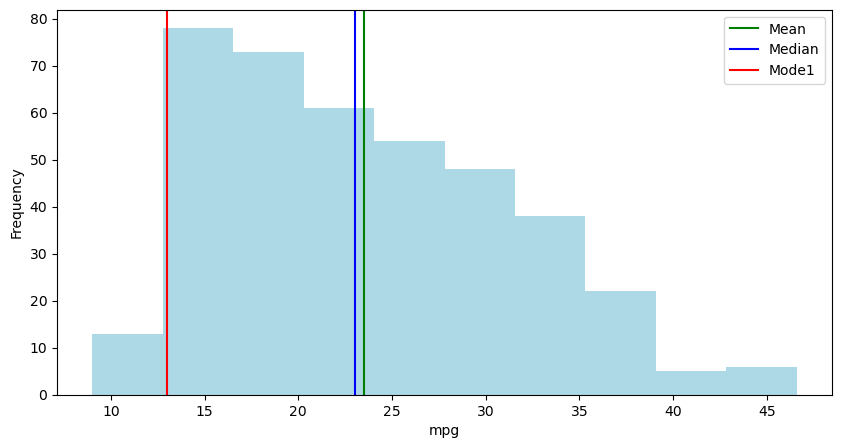

In [15]:
mean=df_dummies['mpg'].mean()
median=df_dummies['mpg'].median()
mode=df_dummies['mpg'].mode()

print('Mean: ',mean,'\nMedian: ',median,'\nMode: ',mode[0])

plt.figure(figsize=(10,5)) # set the figure size
plt.hist(df_dummies['mpg'],bins=10,color='lightblue') #Plot the histogram

plt.axvline(mean,color='green',label='Mean')     # Draw lines on the plot for mean median and the two modes we have in GRE Score
plt.axvline(median,color='blue',label='Median')
plt.axvline(mode[0],color='red',label='Mode1')

plt.xlabel('mpg')   # label the x-axis
plt.ylabel('Frequency')   # label the y-axis
plt.legend()              # Plot the legend
plt.show()

In [16]:
df_dummies.cov(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_America,origin_Asia,origin_Europe
mpg,61.089611,-10.308911,-655.402318,-231.067162,-5505.211745,9.058930,16.741163,-2.151961,1.380224,0.771738
cylinders,-10.308911,2.893415,168.623214,54.697663,1290.695575,-2.370842,-2.193499,0.498139,-0.269338,-0.228801
displacement,-655.402318,168.623214,10872.199152,3570.094379,82368.423240,-156.332976,-142.717137,32.912987,-18.052001,-14.860986
horsepower,-231.067162,54.697663,3570.094379,1460.969052,27915.978893,-72.370753,-58.474096,8.990678,-4.869062,-4.121616
weight,-5505.211745,1290.695575,82368.423240,27915.978893,717140.990526,-974.899011,-959.946344,245.554833,-149.084497,-96.470337
acceleration,9.058930,-2.370842,-156.332976,-72.370753,-974.899011,7.604848,2.938105,-0.335150,0.120204,0.214946
model year,16.741163,-2.193499,-142.717137,-58.474096,-959.946344,2.938105,13.672443,-0.250636,0.285154,-0.034518
origin_America,-2.151961,0.498139,32.912987,8.990678,245.554833,-0.335150,-0.250636,0.234808,-0.124495,-0.110312
origin_Asia,1.380224,-0.269338,-18.052001,-4.869062,-149.084497,0.120204,0.285154,-0.124495,0.159494,-0.034999
origin_Europe,0.771738,-0.228801,-14.860986,-4.121616,-96.470337,0.214946,-0.034518,-0.110312,-0.034999,0.145311


In [17]:
df_dummies.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_America,origin_Asia,origin_Europe
mpg,1.000000,-0.775396,-0.804203,-0.773453,-0.831741,0.420289,0.579267,-0.568192,0.442174,0.259022
cylinders,-0.775396,1.000000,0.950721,0.841284,0.896017,-0.505419,-0.348746,0.604351,-0.396479,-0.352861
displacement,-0.804203,0.950721,1.000000,0.895778,0.932824,-0.543684,-0.370164,0.651407,-0.433505,-0.373886
horsepower,-0.773453,0.841284,0.895778,1.000000,0.862442,-0.686590,-0.413733,0.485418,-0.318972,-0.282877
weight,-0.831741,0.896017,0.932824,0.862442,1.000000,-0.417457,-0.306564,0.598398,-0.440817,-0.298843
acceleration,0.420289,-0.505419,-0.543684,-0.686590,-0.417457,1.000000,0.288137,-0.250806,0.109144,0.204473
model year,0.579267,-0.348746,-0.370164,-0.413733,-0.306564,0.288137,1.000000,-0.139883,0.193101,-0.024489
origin_America,-0.568192,0.604351,0.651407,0.485418,0.598398,-0.250806,-0.139883,1.000000,-0.643317,-0.597198
origin_Asia,0.442174,-0.396479,-0.433505,-0.318972,-0.440817,0.109144,0.193101,-0.643317,1.000000,-0.229895
origin_Europe,0.259022,-0.352861,-0.373886,-0.282877,-0.298843,0.204473,-0.024489,-0.597198,-0.229895,1.000000


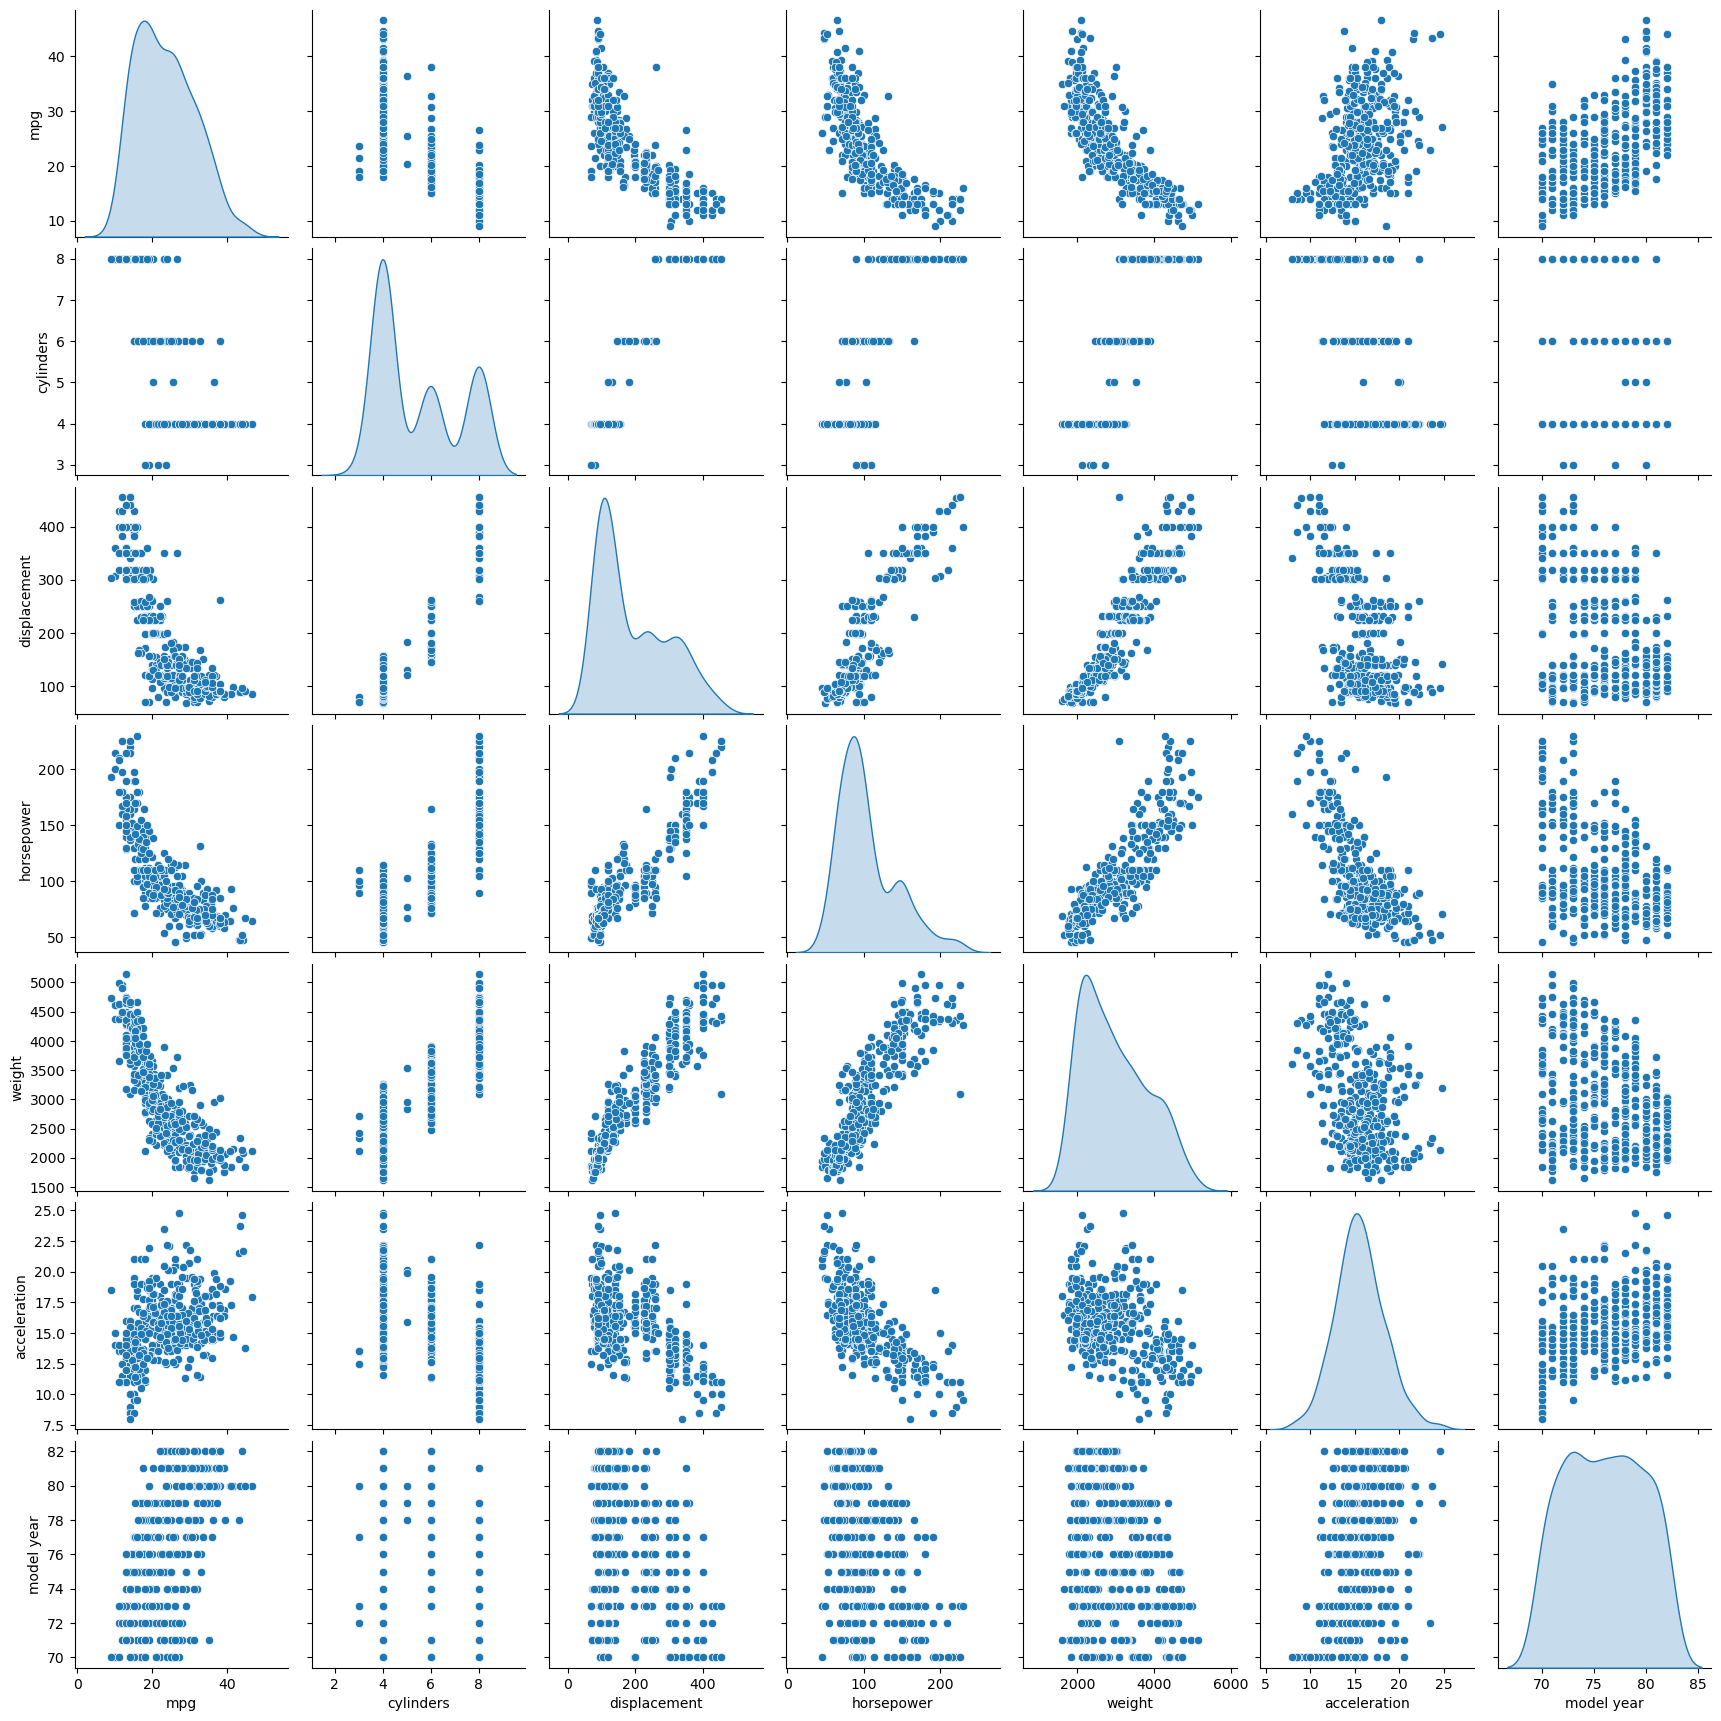

In [18]:
sns.pairplot(df_dummies.iloc[:, 0:7], diag_kind='kde');   # to plot density curve instead of histogram on the diag

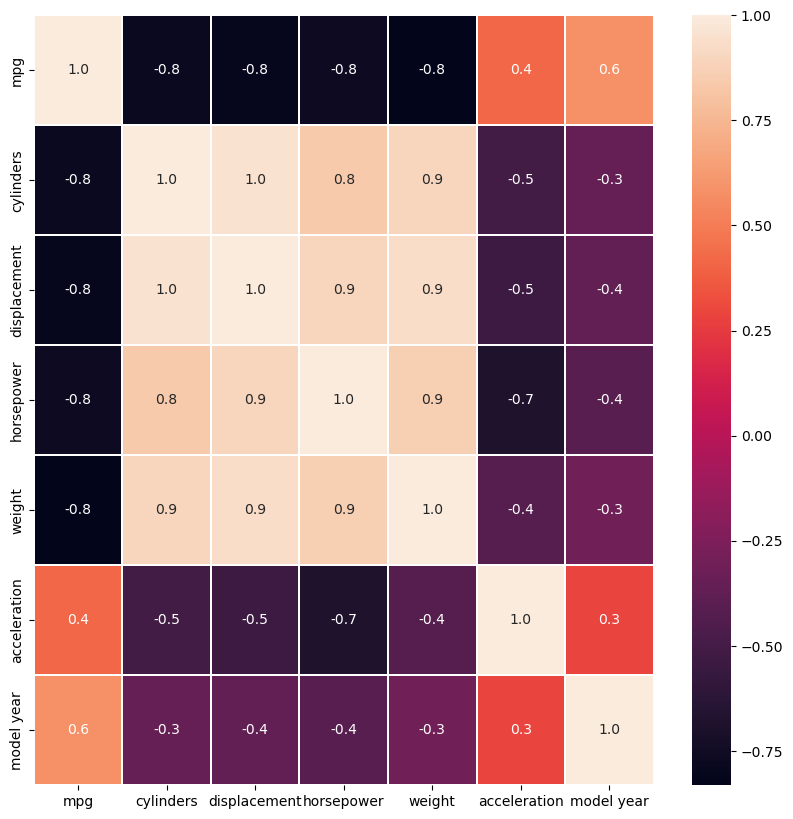

In [19]:
fig,ax = plt.subplots(figsize=(10, 10))   
sns.heatmap(data.corr(numeric_only=True), ax=ax, annot=True, linewidths=0.05, fmt= '.1f') # the color intensity is based on 
plt.show()

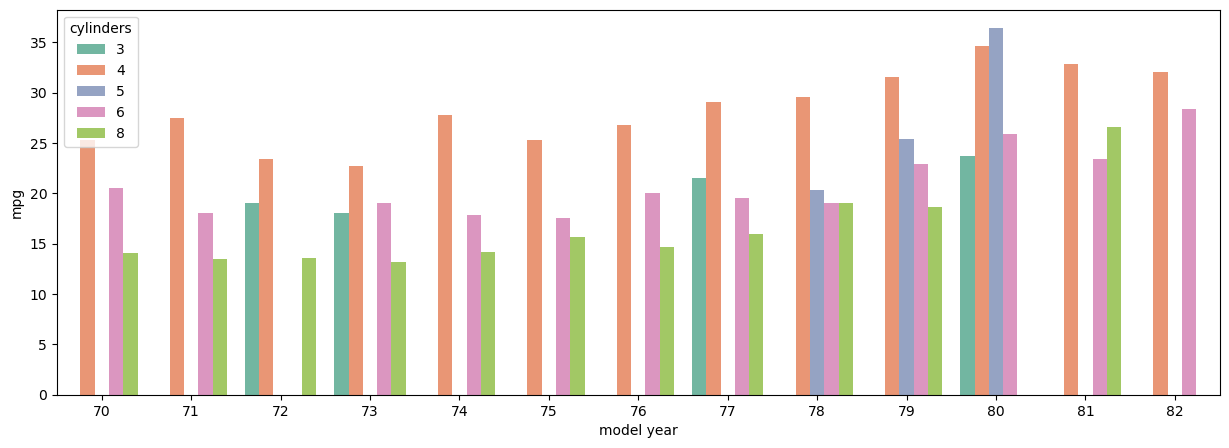

In [20]:
data_mpg = data['mpg'].groupby([data['model year'], data['cylinders']]).mean().reset_index().sort_values(['mpg'],ascending= False)
plt.subplots(figsize=(15,5))
sns.barplot(data=data_mpg,x='model year',y='mpg',hue='cylinders',palette='Set2');

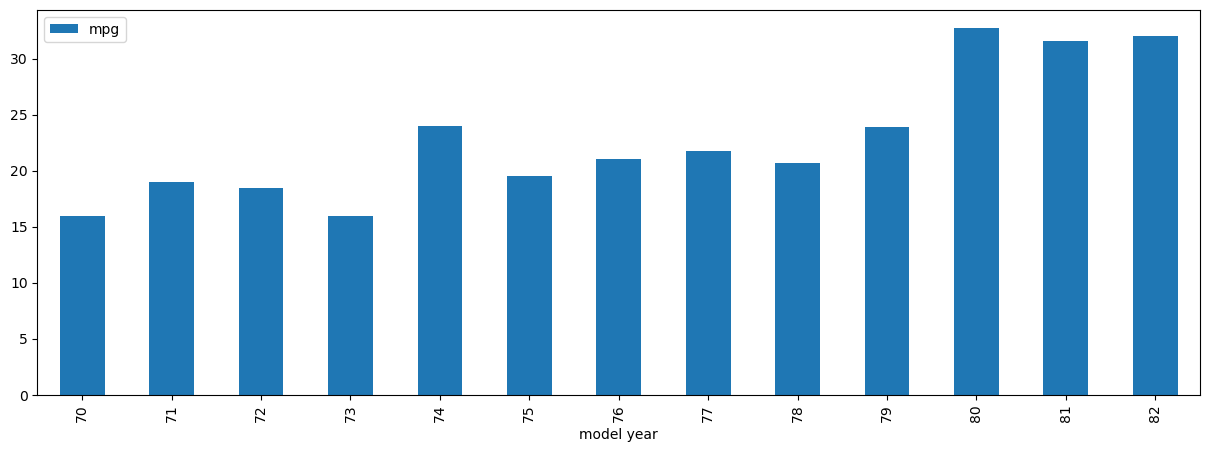

In [21]:
df_dummies.groupby('model year').median().reset_index().plot(x='model year',y='mpg',kind='bar',figsize=(15,5));

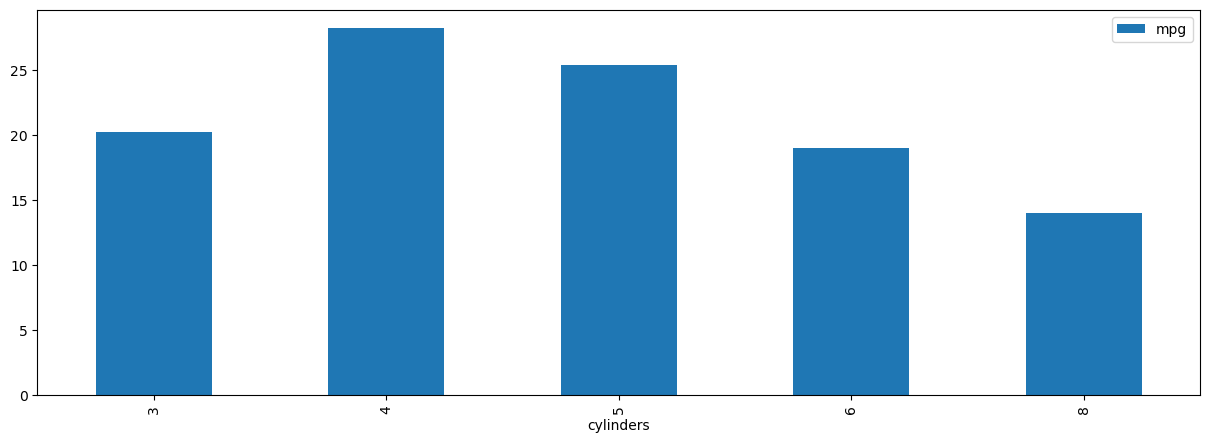

In [22]:
df_dummies.groupby('cylinders').median().reset_index().plot(x='cylinders',y='mpg',kind='bar',figsize=(15,5));

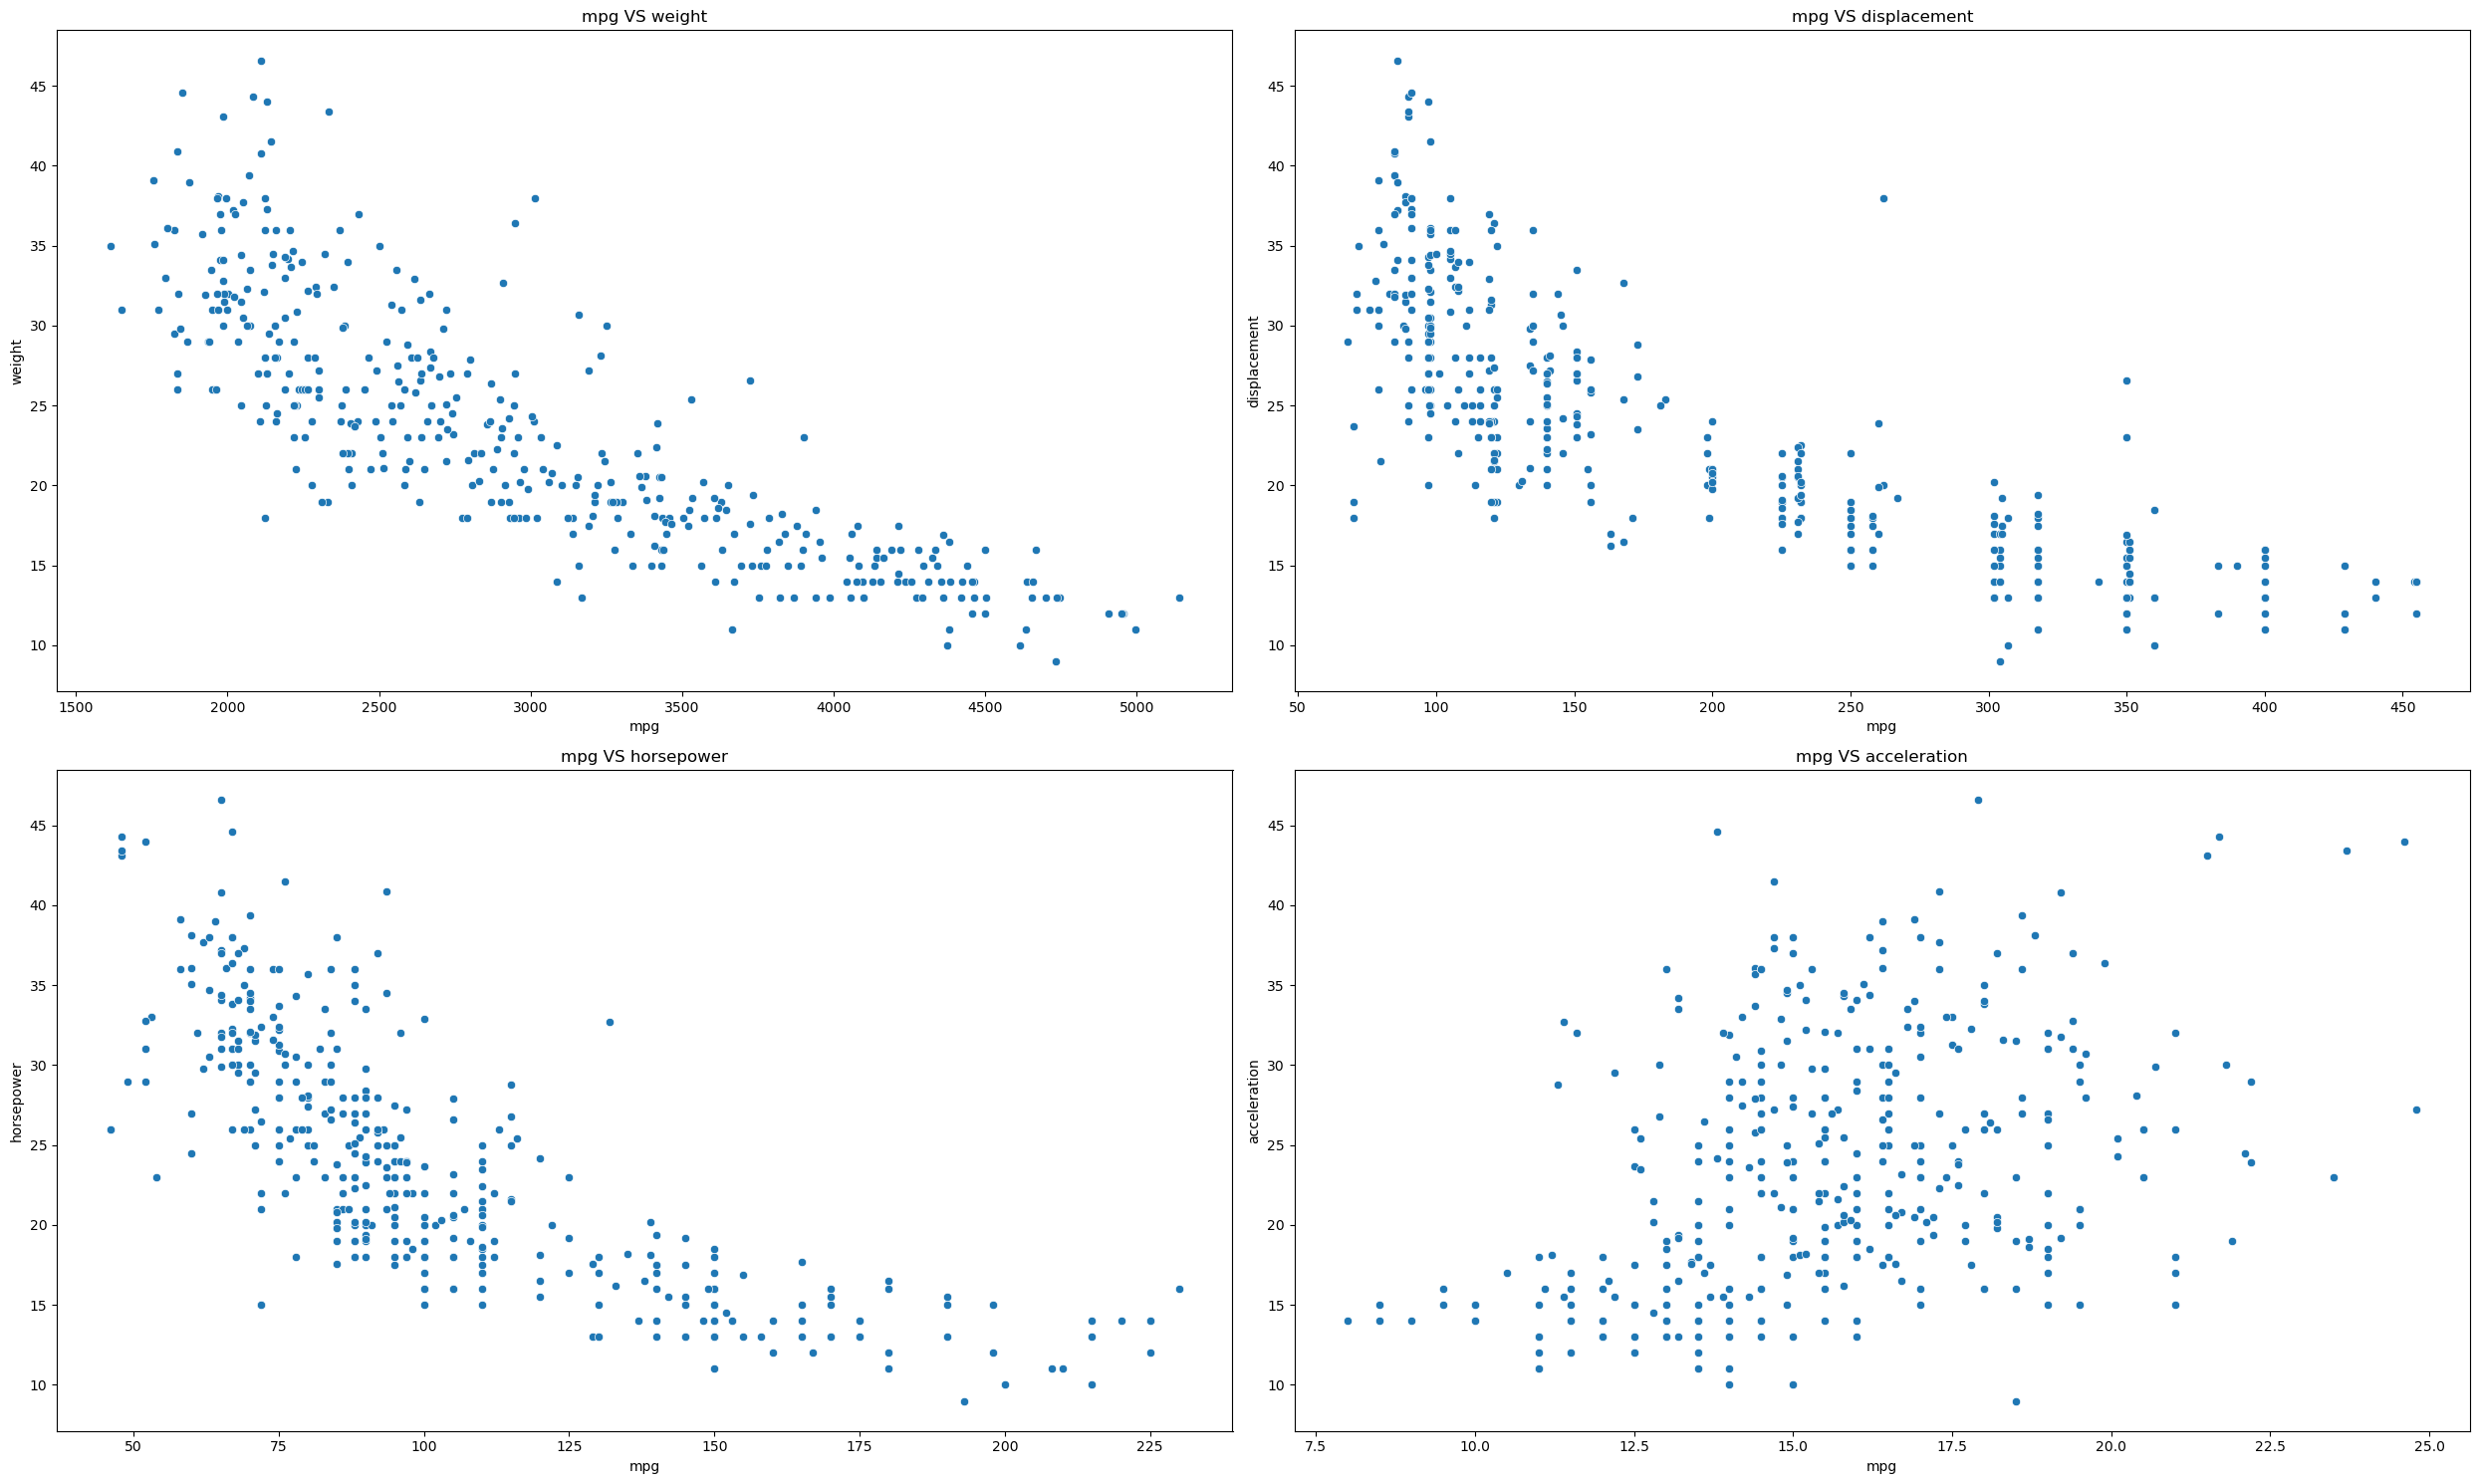

In [23]:
plt.figure(figsize = [25, 15])

plt.subplot(221); sns.scatterplot(data=data, x='weight',y='mpg'); plt.title("mpg VS weight"); plt.xlabel('mpg'); plt.ylabel('weight')
plt.subplot(222); sns.scatterplot(data=data, x='displacement',y='mpg'); plt.title("mpg VS displacement"); plt.xlabel('mpg'); plt.ylabel('displacement')
plt.subplot(223); sns.scatterplot(data=data, x='horsepower',y='mpg'); plt.title("mpg VS horsepower"); plt.xlabel('mpg'); plt.ylabel('horsepower')
plt.subplot(224); sns.scatterplot(data=data, x='acceleration',y='mpg'); plt.title("mpg VS acceleration"); plt.xlabel('mpg'); plt.ylabel('acceleration')

plt.tight_layout()

In [24]:
# Split data

In [25]:
X = df_dummies.drop(['mpg'], axis=1)
y = df_dummies[['mpg']]

In [26]:
# Split train and test data into 70:30 ratio

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

In [27]:
print(X_train.shape)

(278, 9)


In [28]:
#Fit linear Model

In [29]:
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression()

In [30]:
# coefficents and intercept of the line
regression_model.coef_[0]

array([-0.39480797,  0.02894551, -0.02175221, -0.00735203,  0.06191937,
        0.83693389, -1.79884935,  0.59641569,  1.20243366])

In [31]:
regression_model.intercept_[0]

-19.485884771453346

In [32]:
for idx, cols in enumerate(X_train.columns):
    print(f"The coefficent of {cols} is {regression_model.coef_[0][idx]}")

The coefficent of cylinders is -0.3948079661648261
The coefficent of displacement is 0.028945510765487487
The coefficent of horsepower is -0.021752207723547134
The coefficent of weight is -0.007352032065147359
The coefficent of acceleration is 0.061919366007619714
The coefficent of model year is 0.8369338917645018
The coefficent of origin_America is -1.7988493458374293
The coefficent of origin_Asia is 0.5964156907563446
The coefficent of origin_Europe is 1.2024336550810846


In [33]:
y_pred = regression_model.predict(X_test)
# y_pred

In [34]:
regression_model.score(X_train, y_train)

0.8141025501610559

In [35]:
regression_model.score(X_test, y_test)

0.8433135132808829

In [36]:
# RMSE score and R2 score
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

Mean squared error: 9.16
Coefficient of determination: 0.84


# Lets scale the data

In [37]:
X_scaled = preprocessing.scale(X)
# y_scaled = preprocessing.scale(y)

In [38]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
# y_scaled = pd.DataFrame(y_scaled, columns=y.columns)

In [39]:
# Split train and test data into 70:30 ratio

X_scaled_train, X_scaled_test, y_scaled_train, y_scaled_test = train_test_split(X_scaled, y, test_size=0.30, random_state=1)

In [40]:
reg_model_scaled = LinearRegression()
reg_model_scaled.fit(X_scaled_train, y_scaled_train)

print(reg_model_scaled.intercept_[0])
print()
print(reg_model_scaled.coef_[0])

23.635648152134063

[-0.67072581  3.0143497  -0.83038131 -6.21818134  0.1705397   3.09077884
 -0.73377088  0.3506362   0.56540477]


In [41]:
y_scaled_pred = reg_model_scaled.predict(X_scaled_test)

print("Test Score")
print(reg_model_scaled.score(X_scaled_test, y_scaled_test))
print("Train Score")
print(reg_model_scaled.score(X_scaled_train, y_scaled_train))

Test Score
0.8433135132808833
Train Score
0.8141025501610559


In [42]:
# RMSE score and R2 score
print("Mean squared error: %.2f" % mean_squared_error(y_scaled_test, y_scaled_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_scaled_test, y_scaled_pred))

Mean squared error: 9.16
Coefficient of determination: 0.84


# Adding interaction term for higher degree of polynomial

In [43]:
poly = PolynomialFeatures(degree=2, interaction_only=True)
X_poly = poly.fit_transform(X_scaled)
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.30, random_state=1)

poly_clf = LinearRegression()
poly_clf.fit(X_train_poly, y_train_poly)

y_pred_poly = poly_clf.predict(X_test_poly)

print("Intercept coeff")
print(poly_clf.intercept_[0])
print("Coeff")
print(poly_clf.coef_[0])
print()
print("Test Score")
print(poly_clf.score(X_test_poly, y_test_poly))
print("Train Score")
print(poly_clf.score(X_train_poly, y_train_poly))
print()
# RMSE score and R2 score
print("Mean squared error: %.2f" % mean_squared_error(y_test_poly, y_pred_poly))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test_poly, y_pred_poly))

Intercept coeff
682554895224.641
Coeff
[-3.68062164e-13 -1.56671819e-02 -5.13530107e-01 -1.92736388e+00
 -5.27786850e+00 -6.16513638e-01  3.06647253e+00 -5.34999114e+09
 -1.14415891e+12  1.05885111e+12 -1.82241655e+00  1.81409645e-01
  2.00332922e+00  1.51361675e+00 -1.53851151e+00  1.46475595e+12
  1.20720590e+12  1.15228101e+12  2.84910186e-01  1.61581097e+00
 -1.02081090e+00  2.60712904e+00  2.91447275e+11  2.40201701e+11
  2.29273116e+11 -6.26577848e-01 -2.61508615e-01 -1.53232412e+00
  1.01422925e+11  8.35895933e+10  7.97864730e+10 -1.36548293e-01
  2.45765883e-01 -5.85654082e+11 -4.82677722e+11 -4.60717076e+11
  5.14993866e-01 -1.55654591e+11 -1.28285631e+11 -1.22448951e+11
 -3.58596593e+10 -2.95544062e+10 -2.82097536e+10 -9.64099384e+10
  1.61366242e+12 -9.53040389e+11]

Test Score
0.8662562160057621
Train Score
0.9026170478540727

Mean squared error: 7.82
Coefficient of determination: 0.87


# Ridge Lasso Regression

In [44]:
ridge = Ridge(alpha=0.3)
ridge.fit(X_scaled_train, y_scaled_train)
print ("Ridge model:", (ridge.coef_))

Ridge model: [[-0.62494625  2.86181924 -0.85010003 -6.11414714  0.14971413  3.07891605
  -0.72666287  0.34868313  0.55841538]]


In [45]:
lasso = Lasso(alpha=0.02)
lasso.fit(X_scaled_train, y_scaled_train)
print ("Lasso model:", (lasso.coef_))

Lasso model: [-0.18176551  1.94163589 -0.76110615 -5.83117329  0.08260845  3.03645943
 -1.04112064  0.          0.20895965]


In [46]:
print("Test Score")
print(reg_model_scaled.score(X_scaled_test, y_scaled_test))
print("Train Score")
print(reg_model_scaled.score(X_scaled_train, y_scaled_train))

Test Score
0.8433135132808833
Train Score
0.8141025501610559


In [47]:
print(ridge.score(X_scaled_train, y_scaled_train))
print(ridge.score(X_scaled_test, y_scaled_test))

0.8140828080856514
0.8437999817350271


In [48]:
print(lasso.score(X_scaled_train, y_scaled_train))
print(lasso.score(X_scaled_test, y_scaled_test))

0.8133645220311537
0.8446897613098777


In [49]:
ridge_poly = Ridge(alpha=.3)
ridge_poly.fit(X_train_poly,y_train_poly)
print ("Ridge model:", (ridge_poly.coef_))

Ridge model: [[ 0.          0.06740642 -0.61900803 -1.97236759 -5.15141317 -0.62282102
   3.04381568  0.1723188   0.15891088 -0.38553368 -1.4895438   0.02925116
   1.72762625  1.4201127  -1.38679985 -0.05712906  1.13569653 -1.11720961
   0.30089657  1.53987731 -0.84218996  2.38658282  0.21457492  0.50684735
  -0.80377008 -0.47592772 -0.30069342 -1.50318104 -0.61710306  0.43440955
   0.32933252 -0.14480549  0.25597746  0.47585604 -0.93880283  0.37865359
   0.4784103  -0.67039722  0.22915648  0.61211567 -0.49887694  0.4033774
   0.21155723 -0.29118156  0.41878367  0.1184465 ]]


In [50]:
print(ridge_poly.score(X_train_poly, y_train_poly))
print(ridge_poly.score(X_test_poly, y_test_poly))


0.9025975935207239
0.8673792928418459


In [51]:
lasso_poly = Lasso(alpha=0.01)
lasso_poly.fit(X_train_poly,y_train_poly)
print ("Lasso model:", (lasso_poly.coef_))

Lasso model: [ 0.         -0.         -0.08692269 -1.94971176 -5.29180738 -0.47273225
  2.98385949 -0.          0.         -0.         -0.79527606 -0.05882027
  1.1561088   1.08164446 -0.9493974  -0.          1.23352833 -0.87530628
 -0.          1.38994992 -0.4329787   1.86995071 -0.          0.
 -0.         -0.         -0.24115467 -1.24997101 -0.6285489   0.
  0.         -0.16019703  0.          0.26564551 -0.61312578 -0.
  0.47635543 -0.89394     0.          0.3945189  -0.68253648  0.12935612
  0.         -0.23102258  0.38217499  0.        ]


In [52]:
print(lasso_poly.score(X_train_poly, y_train_poly))
print(lasso_poly.score(X_test_poly, y_test_poly))

0.9013410674767774
0.8704180363604553


Text(0, 0.5, 'y_pred')

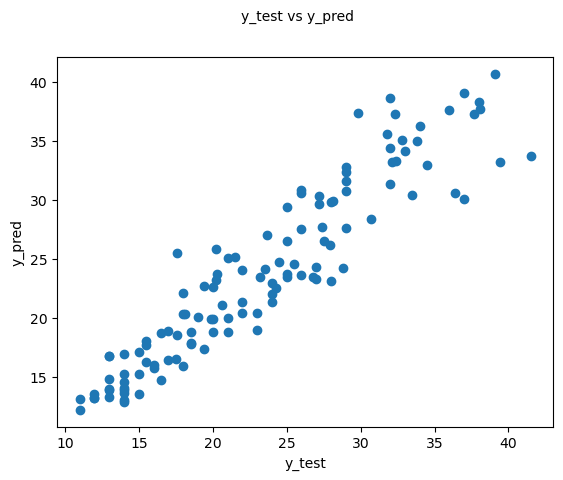

In [55]:
# Plotting y_test and y_pred to understand the spread

fig = plt.figure()
plt.scatter(y_test_poly, y_pred_poly)
fig.suptitle('y_test vs y_pred', fontsize = 10)              # Plot heading 
plt.xlabel('y_test', fontsize = 10)                          # X-label
plt.ylabel('y_pred', fontsize = 10)  

Text(0, 0.5, 'y_pred')

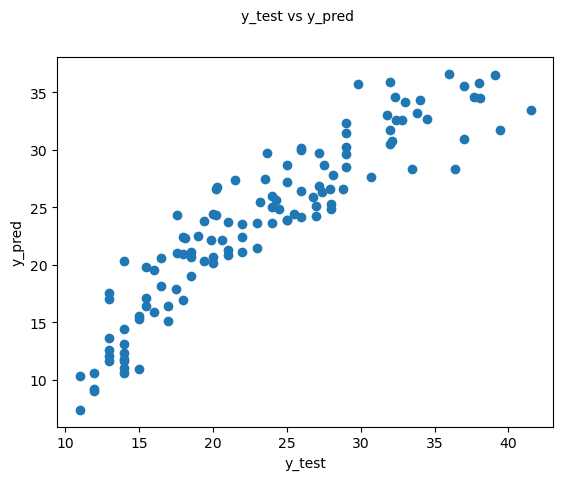

In [56]:
# Plotting y_test and y_pred to understand the spread

fig = plt.figure()
plt.scatter(y_scaled_test, y_scaled_pred)
fig.suptitle('y_test vs y_pred', fontsize = 10)              # Plot heading 
plt.xlabel('y_test', fontsize = 10)                          # X-label
plt.ylabel('y_pred', fontsize = 10)  